In [4]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from datasets import load_dataset
from utils.func import read_jsonl, softmax
from utils.metric import evaluate
from sklearn.metrics import f1_score, precision_recall_curve, accuracy_score

model_name = "LLaVA-7B"

# data = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
# len(data)

### Please evaluate the results use the codes provided by the MathVista repo
After that, you can run the following codes

In [9]:
fix = "_oeh"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.2, l1_ratio=0.5)
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
import collections
print(collections.Counter(y))
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
# Compute accuracy for each threshold
acc_scores = []
for t in thresh:
    y_pred = (y_proba >= t).astype(int)
    acc = accuracy_score(y, y_pred)
    acc_scores.append(acc)

# Accuracy at best F1 threshold
best_thresh = thresh[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print("Accuracy at best F1 threshold:", best_acc)

# (Optional) show some sample thresholds and accuracies
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")
    
# (Optional) print a few threshold–accuracy pairs
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")

import collections
print(collections.Counter(y))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0.7513587  0.8763587  0.88179348 0.83967391 0.73369565 0.88644689
 0.84126984 0.77289377 0.90720391 0.81807082]
[0.79 0.82 0.91 0.83 0.77 0.83 0.88 0.77 0.82 0.84]
[0.27586207 0.4        0.57142857 0.37037037 0.25806452 0.4516129
 0.5        0.34285714 0.47058824 0.38461538]
AUROC: 83.09
ACC: 82.60
F1: 40.25
Counter({0: 915, 1: 85})
Best threshold: 0.7397261484329609
Best F1: 0.4749999950195313
Accuracy at best F1 threshold: 0.916
Threshold=0.001, Accuracy=8.50%
Threshold=0.021, Accuracy=33.00%
Threshold=0.119, Accuracy=56.20%
Threshold=0.414, Accuracy=78.60%
Threshold=0.980, Accuracy=91.40%
Threshold=0.001, Accuracy=8.50%
Threshold=0.021, Accuracy=33.00%
Threshold=0.119, Accuracy=56.20%
Threshold=0.414, Accuracy=78.60%
Threshold=0.980, Accuracy=91.40%
Counter({0: 915, 1: 85})


## OE

In [7]:
fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.2, l1_ratio=0.5)
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
# Compute accuracy for each threshold
acc_scores = []
for t in thresh:
    y_pred = (y_proba >= t).astype(int)
    acc = accuracy_score(y, y_pred)
    acc_scores.append(acc)

# Accuracy at best F1 threshold
best_thresh = thresh[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print("Accuracy at best F1 threshold:", best_acc)

# (Optional) show some sample thresholds and accuracies
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")
    
# (Optional) print a few threshold–accuracy pairs
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")

import collections
print(collections.Counter(y))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0.90364583 0.87239583 0.9609375  0.77864583 0.9375     0.83333333
 0.84635417 0.85263158 0.95789474 0.76631579]
[0.9  0.86 0.94 0.93 0.9  0.88 0.92 0.92 0.95 0.87]
[0.28571429 0.3        0.5        0.22222222 0.375      0.25
 0.33333333 0.33333333 0.28571429 0.13333333]
AUROC: 87.10
ACC: 90.70
F1: 30.19
Best threshold: 0.7785114470512166
Best F1: 0.3448275812075572
Accuracy at best F1 threshold: 0.943
Threshold=0.000, Accuracy=4.30%
Threshold=0.007, Accuracy=28.80%
Threshold=0.020, Accuracy=53.00%
Threshold=0.125, Accuracy=77.20%
Threshold=0.983, Accuracy=95.80%
Threshold=0.000, Accuracy=4.30%
Threshold=0.007, Accuracy=28.80%
Threshold=0.020, Accuracy=53.00%
Threshold=0.125, Accuracy=77.20%
Threshold=0.983, Accuracy=95.80%
Counter({0: 957, 1: 43})


In [ ]:
# fintune
from sklearn.metrics import accuracy_score

fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.metrics import f1_score, precision_recall_curve, accuracy_score
import numpy as np, collections

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])

model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.8, l1_ratio=0.5, max_iter=2000)
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(f"AUROC (CV mean): {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC   (CV mean): {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1    (CV mean): {np.mean(res['test_f1'])*100:.2f}")

# ---- threshold tuning on all data ----
y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr = thresh[best_idx]

print("Best threshold:", best_thr)
print("Best F1:", f1_scores[best_idx])

# apply threshold to get predictions
custom_pred = (y_proba >= best_thr).astype(int)

print("ACC @best_thr:", accuracy_score(y, custom_pred))
print("F1  @best_thr:", f1_score(y, custom_pred))

print(collections.Counter(y))


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [35]:
# grid search
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Assuming X_train, y_train, X_test, y_test are already defined

# Example of hyperparameter tuning with GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'], # 'liblinear' supports both 'l1' and 'l2'
    'class_weight': [None, 'balanced']
}

logistic_model = LogisticRegression(random_state=42)
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"Best F1 score: {f1}")
print(f"Best parameters: {grid_search.best_params_}")

NameError: name 'X_test' is not defined

In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_self_eval.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.5).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")
import collections
print(collections.Counter(y))

AUROC: 59.60
ACC: 77.70
F1: 87.32


In [31]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_oeh.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.5).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")


AUROC: 41.84
ACC: 36.10
F1: 52.42


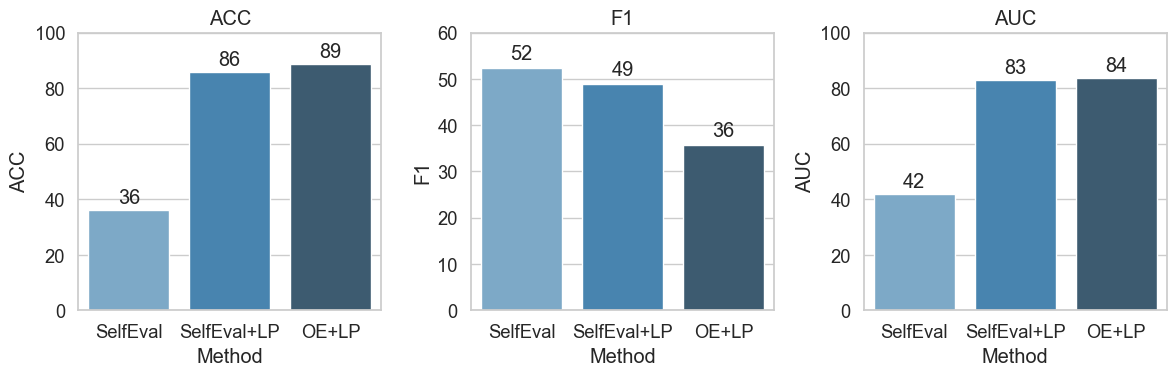

In [8]:
# after finetuning
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your results
data = {
    "Method": ["SelfEval", "SelfEval+LP", "OE+LP"],
    "ACC": [36.10, 85.80, 88.52],
    "F1": [52.42, 48.88, 35.71],
    "AUC": [41.84, 82.94, 83.66],
}

df = pd.DataFrame(data)

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ACC plot
sns.barplot(ax=axes[0], x="Method", y="ACC", data=df, palette="Blues_d")
for idx, val in enumerate(df["ACC"]):
    axes[0].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[0].set_ylim(0, 100)

# F1 plot
sns.barplot(ax=axes[1], x="Method", y="F1", data=df, palette="Blues_d")
for idx, val in enumerate(df["F1"]):
    axes[1].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[1].set_ylim(0, 60)

# AUC plot
sns.barplot(ax=axes[2], x="Method", y="AUC", data=df, palette="Blues_d")
for idx, val in enumerate(df["AUC"]):
    axes[2].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[2].set_ylim(0, 100)

# Titles
axes[0].set_title("ACC")
axes[1].set_title("F1")
axes[2].set_title("AUC")

plt.tight_layout()
plt.show()


In [10]:
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)

ImportError: cannot import name 'UnsetMetadataPassedError' from 'sklearn.exceptions' (C:\Users\he-yu\anaconda3\envs\LVLM-LP\lib\site-packages\sklearn\exceptions.py)